Dataset loaded successfully!
TABEL 2.1 - Statistici Descriptive:
        temperature      humidity           co2         sound
count  51186.000000  51186.000000  51186.000000  51186.000000
mean      20.690131     44.295776    520.591511     50.779520
std        1.205284      6.741725     77.147816      2.590282
min       18.333000     26.759000    424.946000     21.999000
25%       19.642250     39.796250    460.727250     49.088000
50%       20.657000     43.921000    496.654000     50.199000
75%       21.609000     48.894750    559.094000     51.363750
max       24.614000     66.856000    908.562000     68.435000


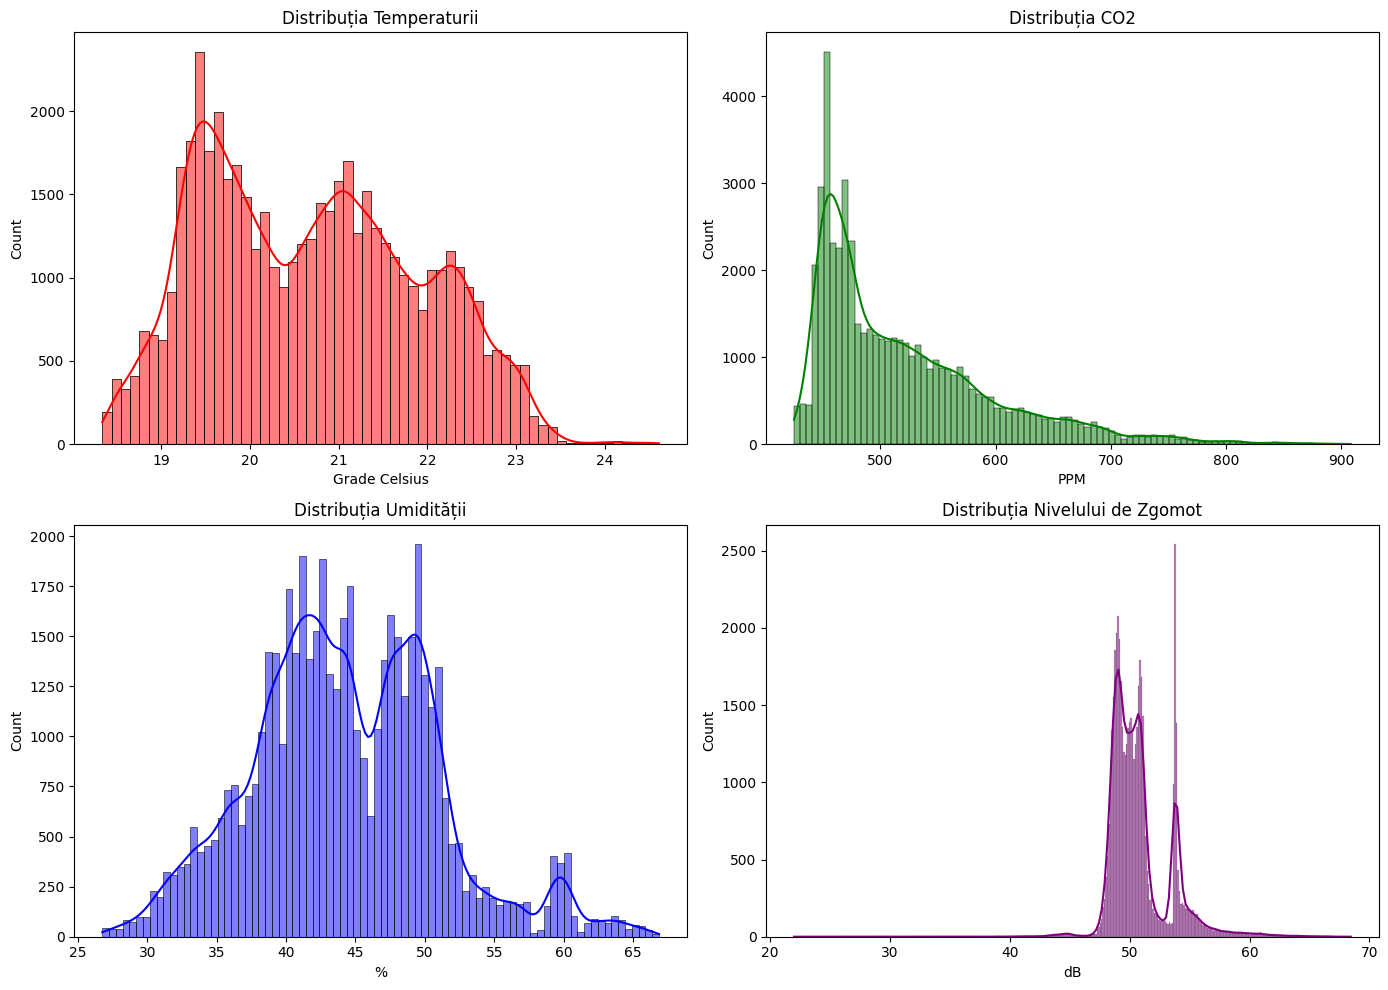

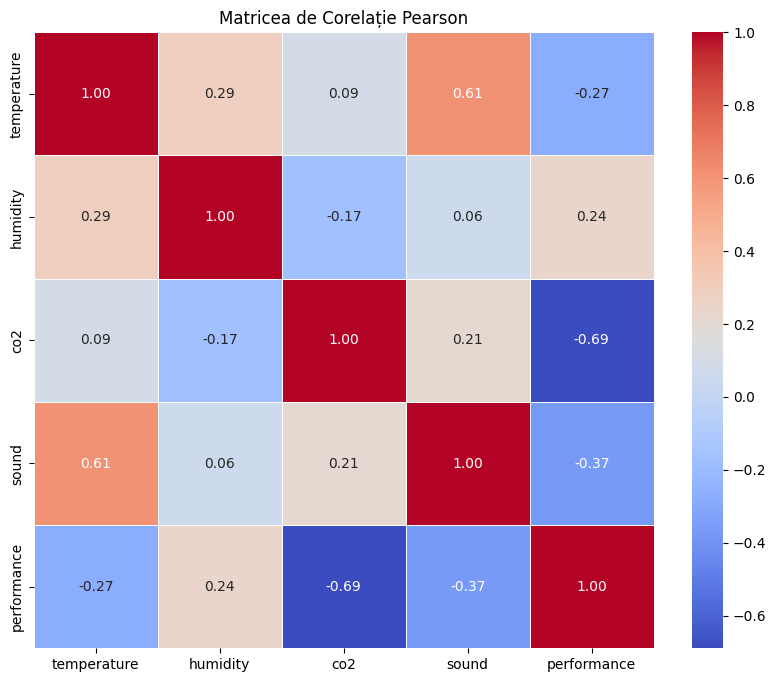


>>> 2. Advanced Pre-processing & Visualization...


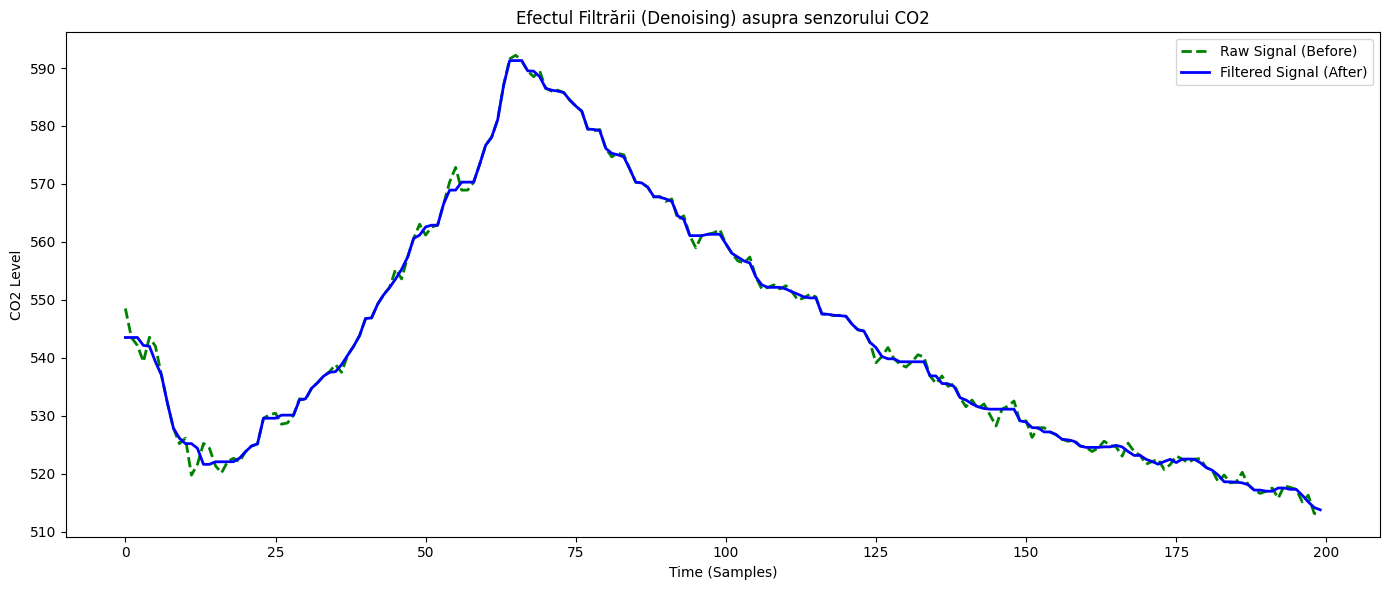

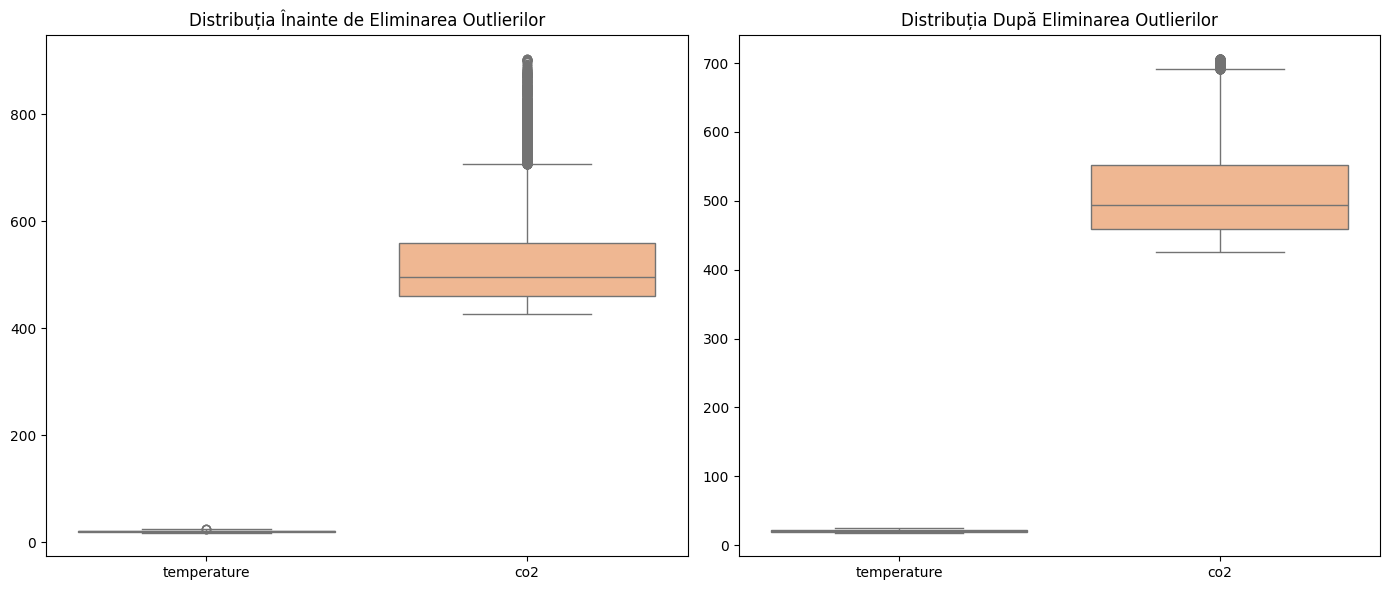

Dimensiuni finale dataset după curățare: (49654, 7)

>>> 3. Feature Selection (Recursive Feature Elimination)...
Top caracteristici selectate: ['co', 'temperature', 'co2', 'humidity', 'sound']

>>> 4. Data Splitting (70% Train, 10% Val, 20% Test)...
Train samples: 34757
Validation samples: 4966
Test samples: 9931

>>> 5. Training Random Forest Model...

>>> 6. Model Evaluation...
-----------------------------------
REZULTATE VALIDARE (10% subset):
RMSE: 12.6968 | R2 Score: 0.9730
-----------------------------------
REZULTATE TEST FINAL (20% subset):
RMSE: 12.0277 | R2 Score: 0.9746
-----------------------------------


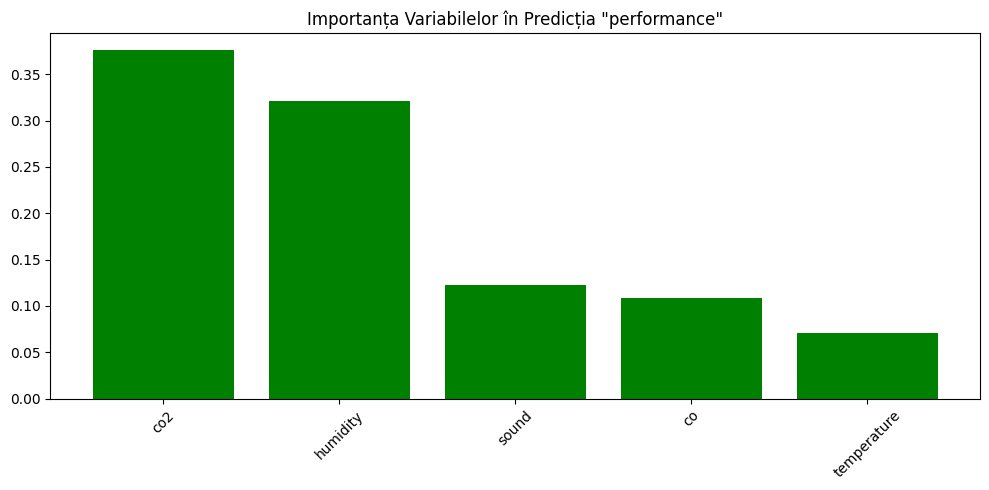

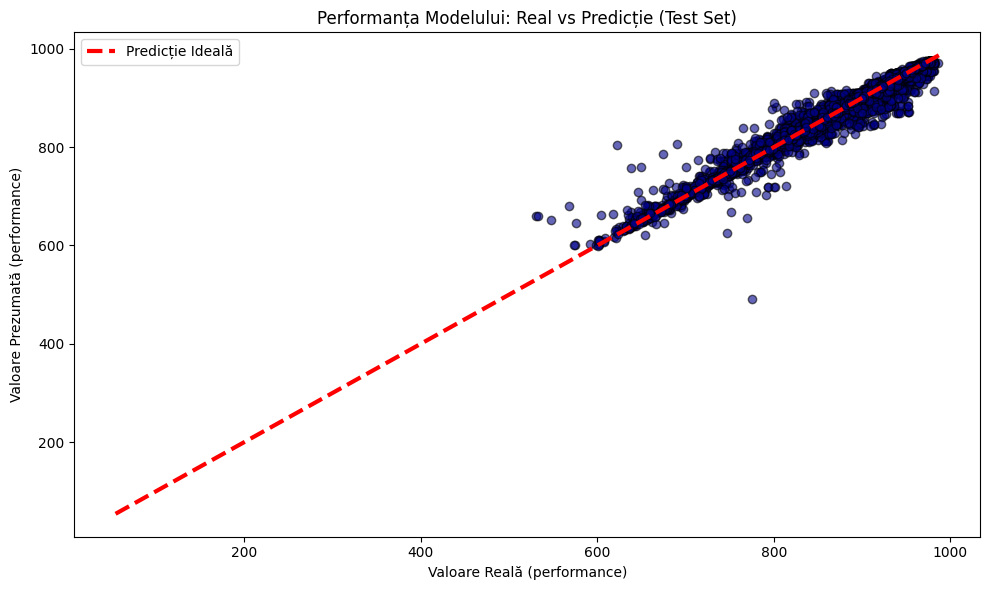

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from scipy.ndimage import median_filter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


file_path = "D:\\FACULTATE\\An3 Facultate\\SBC\\ProiectSBC\\16 - Indoor Air Quality Monitoring and Control System\\archive 3\\laboratory.csv"


# ==========================================
# 1. ÎNCĂRCARE ȘI PREGĂTIRE DATE
# ==========================================


try:
    df_raw = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"EROARE CRITICĂ: Nu am găsit fișierul la {file_path}")


# Eliminăm coloanele inutile sau redundante (conform analizei inițiale)
cols_to_drop = [
    'TypPS', 'pm10', 'cnt0_5', 'measuretime', 'so2', 'no2', 'cnt5', 'timestamp',
    'pm1', 'cnt1', 'dwept', 'tvoc', 'pressure', 'cnt10', 'dCO2dt', 'sound_max',
    'health', 'temperature_o2', 'cnt2_5', 'o3', 'dHdt', 'humidity_abs', 
    'pm2_5', 'cnt0_3', 'cnt1', 'dewpt'
]


# Păstrăm doar ce există în dataframe pentru a evita erori
existing_cols = [c for c in cols_to_drop if c in df_raw.columns]
df_working = df_raw.drop(columns=existing_cols)

# Facem o copie "Raw" pentru graficele comparative "Before"
df_before_processing = df_working.copy()

# Tratarea valorilor lipsă: Interpolare liniară (ideală pentru serii de timp/senzori)
df_working = df_working.interpolate(method='linear').dropna()
# 1. STATISTICI DESCRIPTIVE

cols_to_analyze = ['temperature', 'humidity', 'co2', 'sound']
desc_stats = df_working[cols_to_analyze].describe()
print("TABEL 2.1 - Statistici Descriptive:")
print(desc_stats)

# 2. ANALIZA VIZUALĂ: DISTRIBUȚII 
plt.figure(figsize=(14, 10))

# Temperatura
plt.subplot(2, 2, 1)
sns.histplot(df_working['temperature'], kde=True, color='red')
plt.title('Distribuția Temperaturii')
plt.xlabel('Grade Celsius')

# CO2
plt.subplot(2, 2, 2)
sns.histplot(df_working['co2'], kde=True, color='green')
plt.title('Distribuția CO2')
plt.xlabel('PPM')

# Umiditate
plt.subplot(2, 2, 3)
sns.histplot(df_working['humidity'], kde=True, color='blue')
plt.title('Distribuția Umidității')
plt.xlabel('%')

# Sound (Sunet)
plt.subplot(2, 2, 4)
sns.histplot(df_working['sound'], kde=True, color='purple')
plt.title('Distribuția Nivelului de Zgomot')
plt.xlabel('dB')

plt.tight_layout()
plt.show() 

# 3. MATRICEA DE CORELAȚIE
plt.figure(figsize=(10, 8))
cols_corr = ['temperature', 'humidity', 'co2', 'sound', 'performance']
cols_corr = [c for c in cols_corr if c in df_working.columns]

corr_matrix = df_working[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matricea de Corelație Pearson')
plt.show() 

# ==========================================
# 2. PROCESARE AVANSATĂ & VIZUALIZARE 
# ==========================================
print("\n>>> 2. Advanced Pre-processing & Visualization...")

# --- A. Denoising (Filtrare Mediană) ---

cols_to_filter = ['temperature', 'humidity', 'co2', 'sound']
# Filtrăm doar coloanele care există efectiv în setul de date
cols_to_filter = [c for c in cols_to_filter if c in df_working.columns]


for col in cols_to_filter:
    df_working[col] = median_filter(df_working[col], size=5)

# >>> GRAFIC 1: Denoising - Before vs After <<<
if 'co2' in df_working.columns:
    plt.figure(figsize=(14, 6))
    plt.plot(df_before_processing['co2'].values[:200], label='Raw Signal (Before)', color='green', linestyle='--', linewidth=2)
    plt.plot(df_working['co2'].values[:200], label='Filtered Signal (After)', color='blue', linewidth=2)
    plt.title('Efectul Filtrării (Denoising) asupra senzorului CO2')
    plt.xlabel('Time (Samples)')
    plt.ylabel('CO2 Level')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- B. Eliminare Outlieri (Metoda IQR) ---
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Salvăm starea intermediară
df_before_outliers = df_working.copy()

# Aplicăm eliminarea outlierilor pe variabilele critice
if 'temperature' in df_working.columns:
    df_working = remove_outliers_iqr(df_working, 'temperature')
if 'co2' in df_working.columns:
    df_working = remove_outliers_iqr(df_working, 'co2')

# >>> GRAFIC 2: Outlier Removal - Before vs After (Boxplots) <<<
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cols_for_boxplot = [c for c in ['temperature', 'co2'] if c in df_working.columns]
if cols_for_boxplot:
    # Boxplot înainte
    sns.boxplot(data=df_before_outliers[cols_for_boxplot], ax=axes[0], palette='pastel')
    axes[0].set_title('Distribuția Înainte de Eliminarea Outlierilor')

    # Boxplot după
    sns.boxplot(data=df_working[cols_for_boxplot], ax=axes[1], palette='pastel')
    axes[1].set_title('Distribuția După Eliminarea Outlierilor')

    plt.tight_layout()
    plt.show()

print(f"Dimensiuni finale dataset după curățare: {df_working.shape}")

# ==========================================
# 3. FEATURE SELECTION 
# ==========================================
print("\n>>> 3. Feature Selection (Recursive Feature Elimination)...")

# Definim ținta: 'performance' (feedback ocupant)
target_col = 'performance' 
if target_col not in df_working.columns:
    print(f"Info: Coloana '{target_col}' nu a fost găsită. Vom folosi 'temperature' ca target.")
    target_col = 'temperature'

# Separăm datele
X = df_working.drop(columns=[target_col])
y = df_working[target_col]

# Selectăm automat cele mai relevante 5 variabile
model_rfe = RandomForestRegressor(n_jobs=-1, random_state=42)
rfe = RFE(estimator=model_rfe, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_].tolist()
print(f"Top caracteristici selectate: {selected_features}")

# Păstrăm doar variabilele selectate
X_selected = X[selected_features]

# ==========================================
# 4. SPLIT DATA & SCALING 
# ==========================================
print("\n>>> 4. Data Splitting (70% Train, 10% Val, 20% Test)...")

# Etapa 1: 80% (Train+Val) și 20% (Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scalare Standard (Media 0, Deviația 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. PREDICTIVE MODELING - RANDOM FOREST 
# ==========================================
print("\n>>> 5. Training Random Forest Model...")

rf_model = RandomForestRegressor(
    n_estimators=100,  # Număr arbori
    max_depth=10,      # Adâncime pentru a preveni overfitting
    random_state=42,
    n_jobs=-1
)

# Antrenare
rf_model.fit(X_train_scaled, y_train)

# ==========================================
# 6. EVALUARE ȘI REZULTATE 
# ==========================================
print("\n>>> 6. Model Evaluation...")

# A. Validare (pentru tuning fin)
y_pred_val = rf_model.predict(X_val_scaled)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print("-" * 35)
print(f"REZULTATE VALIDARE (10% subset):\nRMSE: {rmse_val:.4f} | R2 Score: {r2_val:.4f}")
print("-" * 35)

# B. Testare Finală 
y_pred_test = rf_model.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"REZULTATE TEST FINAL (20% subset):\nRMSE: {rmse_test:.4f} | R2 Score: {r2_test:.4f}")
print("-" * 35)

# ==========================================
# 7. VIZUALIZARE REZULTATE FINALE
# ==========================================

# >>> GRAFIC 3: Feature Importance <<<
# Ne arată ce factori influențează cel mai mult confortul
plt.figure(figsize=(10, 5))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title(f'Importanța Variabilelor în Predicția "{target_col}"')
plt.bar(range(X_train.shape[1]), importances[indices], color='green', align='center')
plt.xticks(range(X_train.shape[1]), [selected_features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# >>> GRAFIC 4: Actual vs Predicted Scatter <<<
# Ne arată cât de precise sunt predicțiile față de realitate
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkblue', edgecolors='k')
# Linia de referință (predicție perfectă)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Predicție Ideală')
plt.xlabel(f'Valoare Reală ({target_col})')
plt.ylabel(f'Valoare Prezumată ({target_col})')
plt.title('Performanța Modelului: Real vs Predicție (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()





>>> 1. Loading Data...
Dataset loaded successfully!

>>> 2. Advanced Pre-processing & Visualization...


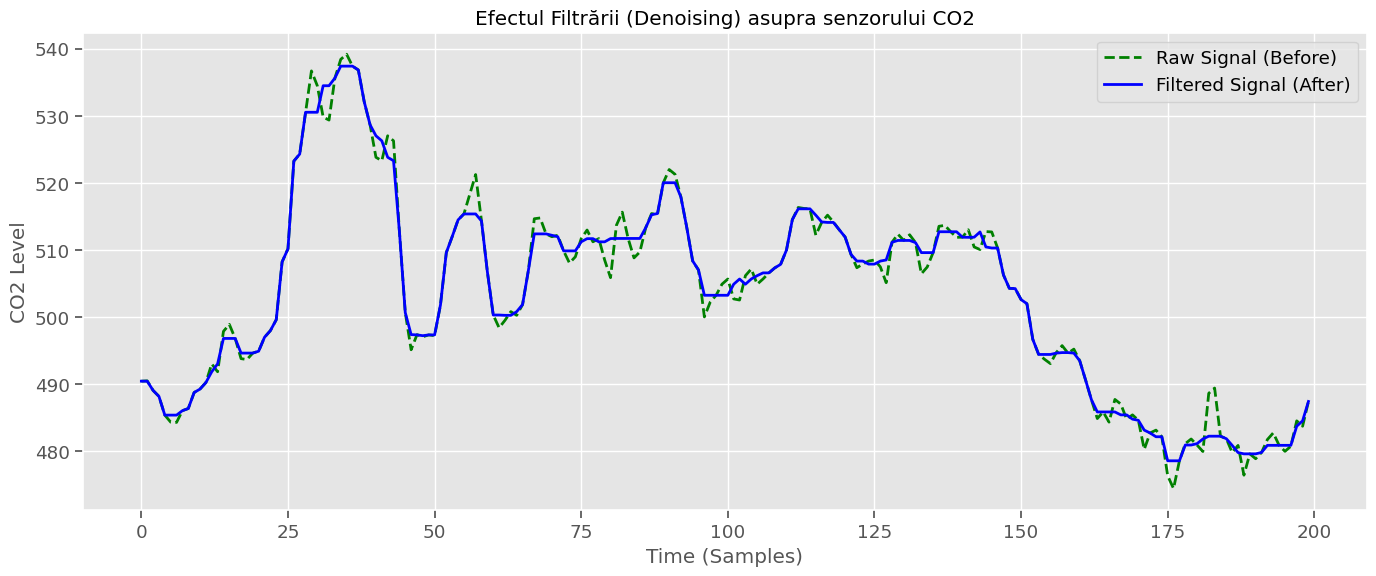

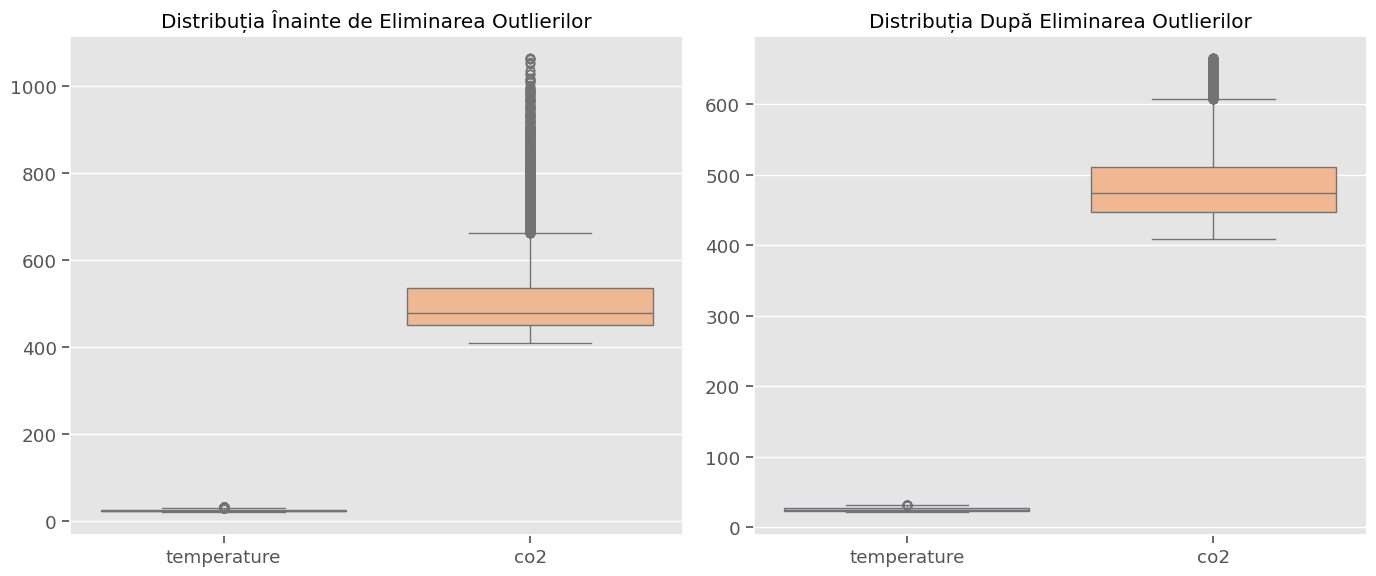

Dimensiuni finale dataset după curățare: (11064, 7)

>>> 3. Feature Selection (Recursive Feature Elimination)...
Top caracteristici selectate: ['oxygen', 'co', 'temperature', 'co2', 'humidity']

>>> 4. Data Splitting (70% Train, 10% Val, 20% Test)...
Train samples: 7744
Validation samples: 1107
Test samples: 2213

>>> 5. Training Random Forest Model...

>>> 6. Model Evaluation...
-----------------------------------
REZULTATE VALIDARE (10% subset):
RMSE: 78.7429 | R2 Score: 0.8922
-----------------------------------
REZULTATE TEST FINAL (20% subset):
RMSE: 79.7899 | R2 Score: 0.8953
-----------------------------------


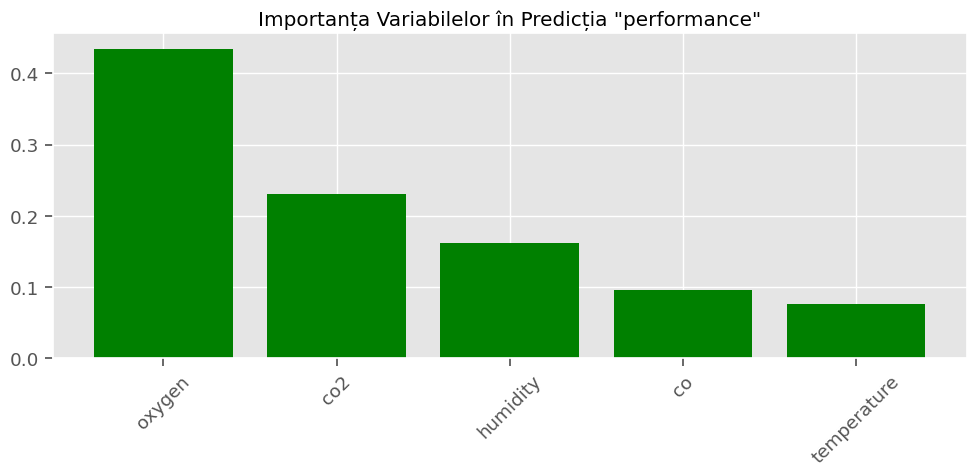

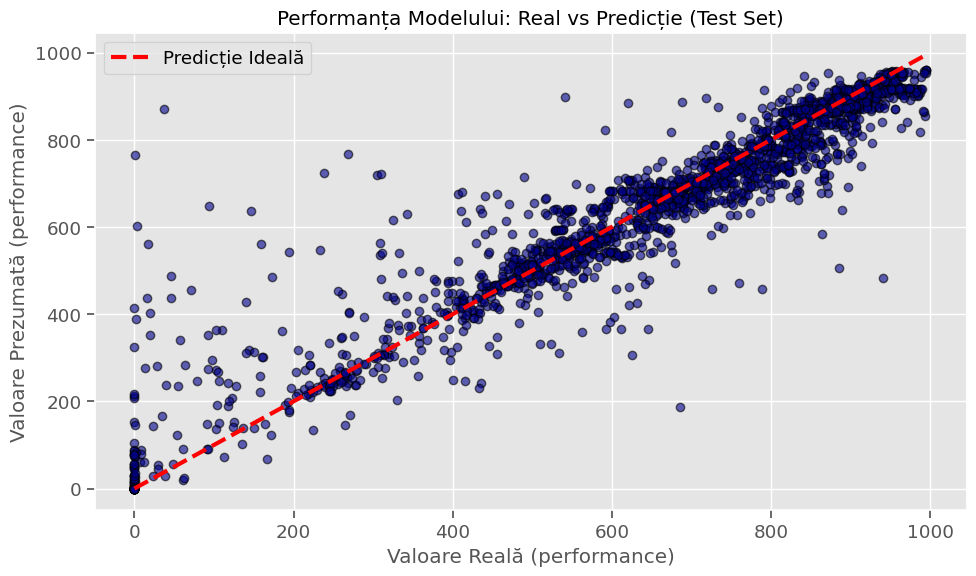

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from scipy.ndimage import median_filter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


wr.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.2)

# ==========================================
# 1. ÎNCĂRCARE ȘI PREGĂTIRE DATE
# ==========================================
print(">>> 1. Loading Data...")

file_path = "D:\\FACULTATE\\An3 Facultate\\SBC\\ProiectSBC\\16 - Indoor Air Quality Monitoring and Control System\\archive 3\\one_room_apartement.csv"

try:
    df_raw = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"EROARE CRITICĂ: Nu am găsit fișierul la {file_path}")
    print("Te rog verifică calea și numele fișierului.")

# Eliminăm coloanele inutile sau redundante 
cols_to_drop = [
    'TypPS', 'pm10', 'cnt0_5', 'measuretime', 'so2', 'no2', 'cnt5', 'timestamp',
    'pm1', 'cnt1', 'dwept', 'tvoc', 'pressure', 'cnt10', 'dCO2dt', 'sound_max',
    'health', 'temperature_o2', 'cnt2_5', 'o3', 'dHdt', 'humidity_abs', 
    'pm2_5', 'cnt0_3', 'cnt1', 'dewpt'
]
# Păstrăm doar ce există în dataframe pentru a evita erori
existing_cols = [c for c in cols_to_drop if c in df_raw.columns]
df_working = df_raw.drop(columns=existing_cols)

# Facem o copie "Raw" pentru graficele comparative "Before"
df_before_processing = df_working.copy()

# Tratarea valorilor lipsă: Interpolare liniară 
df_working = df_working.interpolate(method='linear').dropna()

# ==========================================
# 2. PROCESARE AVANSATĂ & VIZUALIZARE 
# ==========================================
print("\n>>> 2. Advanced Pre-processing & Visualization...")

# --- A. Denoising (Filtrare Mediană) ---

cols_to_filter = ['temperature', 'humidity', 'co2', 'sound']
# Filtrăm doar coloanele care există efectiv în setul de date
cols_to_filter = [c for c in cols_to_filter if c in df_working.columns]

for col in cols_to_filter:
    df_working[col] = median_filter(df_working[col], size=5)

# >>> GRAFIC 1: Denoising - Before vs After <<<
if 'co2' in df_working.columns:
    plt.figure(figsize=(14, 6))
    plt.plot(df_before_processing['co2'].values[:200], label='Raw Signal (Before)', color='green', linestyle='--', linewidth=2)
    plt.plot(df_working['co2'].values[:200], label='Filtered Signal (After)', color='blue', linewidth=2)
    plt.title('Efectul Filtrării (Denoising) asupra senzorului CO2')
    plt.xlabel('Time (Samples)')
    plt.ylabel('CO2 Level')
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- B. Eliminare Outlieri (Metoda IQR) ---
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Salvăm starea intermediară
df_before_outliers = df_working.copy()

# Aplicăm eliminarea outlierilor pe variabilele critice
if 'temperature' in df_working.columns:
    df_working = remove_outliers_iqr(df_working, 'temperature')
if 'co2' in df_working.columns:
    df_working = remove_outliers_iqr(df_working, 'co2')

# >>> GRAFIC 2: Outlier Removal - Before vs After (Boxplots) <<<
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cols_for_boxplot = [c for c in ['temperature', 'co2'] if c in df_working.columns]
if cols_for_boxplot:
    # Boxplot înainte
    sns.boxplot(data=df_before_outliers[cols_for_boxplot], ax=axes[0], palette='pastel')
    axes[0].set_title('Distribuția Înainte de Eliminarea Outlierilor')

    # Boxplot după
    sns.boxplot(data=df_working[cols_for_boxplot], ax=axes[1], palette='pastel')
    axes[1].set_title('Distribuția După Eliminarea Outlierilor')

    plt.tight_layout()
    plt.show()

print(f"Dimensiuni finale dataset după curățare: {df_working.shape}")

# ==========================================
# 3. FEATURE SELECTION - RFE (Lab 5)
# ==========================================
print("\n>>> 3. Feature Selection (Recursive Feature Elimination)...")

# Definim ținta: 'performance' (feedback ocupant)
target_col = 'performance' 
if target_col not in df_working.columns:
    print(f"Info: Coloana '{target_col}' nu a fost găsită. Vom folosi 'temperature' ca target.")
    target_col = 'temperature'

# Separăm datele
X = df_working.drop(columns=[target_col])
y = df_working[target_col]

# Selectăm automat cele mai relevante 5 variabile
model_rfe = RandomForestRegressor(n_jobs=-1, random_state=42)
rfe = RFE(estimator=model_rfe, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_].tolist()
print(f"Top caracteristici selectate: {selected_features}")

# Păstrăm doar variabilele selectate
X_selected = X[selected_features]

# ==========================================
# 4. SPLIT DATA & SCALING (Lab 6)
# ==========================================
print("\n>>> 4. Data Splitting (70% Train, 10% Val, 20% Test)...")

# Etapa 1: 80% (Train+Val) și 20% (Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42
)

# Etapa 2: Din cei 80%, scoatem 12.5% pentru a obține 10% din total (Validare)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scalare Standard (Media 0, Deviația 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. PREDICTIVE MODELING - RANDOM FOREST 
# ==========================================
print("\n>>> 5. Training Random Forest Model...")

rf_model = RandomForestRegressor(
    n_estimators=100,  # Număr arbori
    max_depth=10,      # Adâncime pentru a preveni overfitting
    random_state=42,
    n_jobs=-1
)

# Antrenare
rf_model.fit(X_train_scaled, y_train)

# ==========================================
# 6. EVALUARE ȘI REZULTATE 
# ==========================================
print("\n>>> 6. Model Evaluation...")

# A. Validare (pentru tuning fin)
y_pred_val = rf_model.predict(X_val_scaled)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print("-" * 35)
print(f"REZULTATE VALIDARE (10% subset):\nRMSE: {rmse_val:.4f} | R2 Score: {r2_val:.4f}")
print("-" * 35)

# B. Testare Finală 
y_pred_test = rf_model.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f"REZULTATE TEST FINAL (20% subset):\nRMSE: {rmse_test:.4f} | R2 Score: {r2_test:.4f}")
print("-" * 35)

# ==========================================
# 7. VIZUALIZARE REZULTATE FINALE
# ==========================================

# >>> GRAFIC 3: Feature Importance <<<
# Ne arată ce factori influențează cel mai mult confortul
plt.figure(figsize=(10, 5))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title(f'Importanța Variabilelor în Predicția "{target_col}"')
plt.bar(range(X_train.shape[1]), importances[indices], color='green', align='center')
plt.xticks(range(X_train.shape[1]), [selected_features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

# >>> GRAFIC 4: Actual vs Predicted Scatter <<<
# Ne arată cât de precise sunt predicțiile față de realitate
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkblue', edgecolors='k')
# Linia de referință (predicție perfectă)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Predicție Ideală')
plt.xlabel(f'Valoare Reală ({target_col})')
plt.ylabel(f'Valoare Prezumată ({target_col})')
plt.title('Performanța Modelului: Real vs Predicție (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()
